In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings(action='ignore')

import os # 파일 시스템 경로 작업을 위해 (CSV 파일 로드 시 유용)

# 데이터 분할 및 모델 선택 도구
from sklearn.model_selection import train_test_split, GridSearchCV

# 전처리 도구
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer

# 머신러닝 모델
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# 모델 평가 지표
from sklearn.metrics import classification_report, accuracy_score, \
    confusion_matrix, precision_score, recall_score, f1_score, roc_auc_score

In [4]:
df = pd.read_csv('./data1/creditcard.csv', encoding='euc-kr')

In [5]:
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [6]:
df = df.drop('Time', axis =1)

In [7]:
df1 = df.drop('Class', axis =1)

In [8]:
pd.isnull(df).sum()

V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64

In [9]:
y =df['Class']

In [10]:
x_train, x_test, y_train, y_test = train_test_split(df1, 
                 y, 
                 test_size= 0.2, 
                 random_state= 11)

In [11]:
scaler1 = StandardScaler()
scaler1.fit(x_train)
x_train_scaled = scaler1.transform(x_train)
x_test_scaled = scaler1.transform(x_test)

#  LogisticRegression

In [12]:
model1 = LogisticRegression(random_state= 11)
model1.fit(x_train_scaled, y_train)
pred1 = model1.predict(x_test_scaled)
accuracy_score(y_test, pred1)

0.9990871107053826

In [13]:
confusion_matrix(y_test, pred1)
print(classification_report(y_test, pred1))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56854
           1       0.82      0.67      0.73       108

    accuracy                           1.00     56962
   macro avg       0.91      0.83      0.87     56962
weighted avg       1.00      1.00      1.00     56962



# DecisionTreeClassifier

In [14]:
model2 = DecisionTreeClassifier()
model2.fit(x_train_scaled, y_train)
pred2 = model2.predict(x_test_scaled)
accuracy_score(y_test, pred2)

0.999385555282469

In [15]:
confusion_matrix(y_test, pred2)
print(classification_report(y_test, pred2))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56854
           1       0.90      0.76      0.82       108

    accuracy                           1.00     56962
   macro avg       0.95      0.88      0.91     56962
weighted avg       1.00      1.00      1.00     56962



# RandomForestClassifier

In [16]:
model3 = RandomForestClassifier(random_state=0, max_depth=8)
model3.fit(x_train_scaled, y_train)
pred3 = model3.predict(x_test_scaled)
accuracy_score(y_test, pred3)

0.9995084442259752

In [17]:
confusion_matrix(y_test, pred3)
print(classification_report(y_test, pred3))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56854
           1       0.97      0.77      0.86       108

    accuracy                           1.00     56962
   macro avg       0.98      0.88      0.93     56962
weighted avg       1.00      1.00      1.00     56962



# XGBoost

In [18]:
le = LabelEncoder()
y_train_encoded = le.fit_transform(y_train)  # Series → 1D array
y_test_encoded = le.transform(y_test)

In [19]:
xgb_model = XGBClassifier(n_estimators=400, learning_rate=0.1, max_depth=3, use_label_encoder=False)
xgb_model.fit(x_train_scaled, y_train_encoded)
xgb_predictions = xgb_model.predict(x_test_scaled)
accuracy_score(y_test_encoded,xgb_predictions)

0.9995084442259752

In [20]:
confusion_matrix(y_test_encoded, xgb_predictions)
print(classification_report(y_test_encoded, xgb_predictions))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56854
           1       0.94      0.79      0.86       108

    accuracy                           1.00     56962
   macro avg       0.97      0.89      0.93     56962
weighted avg       1.00      1.00      1.00     56962



<Axes: >

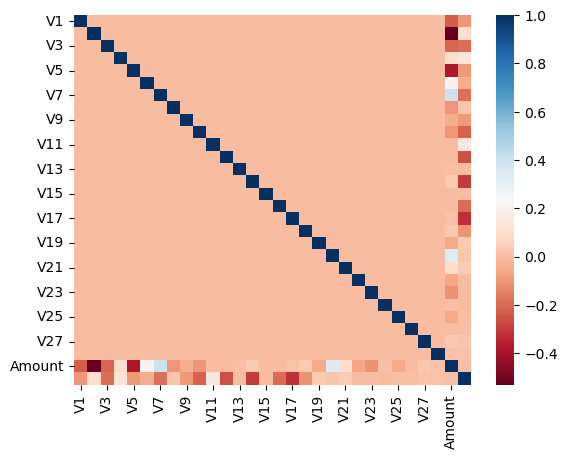

In [21]:
corr=df.corr()
sns.heatmap(corr, cmap='RdBu')

In [22]:
def get_outlier(df=None, column=None, weight=1.5):

    fraud = df[df['Class']==1][column]

    quantile_25 = np.percentile(fraud.values, 25)
    quantile_75 = np.percentile(fraud.values, 75)

    iqr = quantile_75 - quantile_25
    iqr_weight = iqr * weight
    lowest_val = quantile_25 - iqr_weight #lower
    highest_val = quantile_75 + iqr_weight #upper
    
    outlier_index = fraud[(fraud < lowest_val) | (fraud > highest_val)].index
    return outlier_index

In [23]:
outlier_index14 = get_outlier(df = df, column='V14', weight=1.5)
outlier_index14

Index([8296, 8615, 9035, 9252], dtype='int64')

In [24]:
outlier_index17 = get_outlier(df = df, column='V17', weight=1.5)
outlier_index17

Index([], dtype='int64')

In [25]:
def get_preprocessed_df(df=None):
    df_copy = df.copy()

    
    #Amount scaling
    scaler = StandardScaler()
    amount_n = scaler.fit_transform(df_copy['Amount'].values.reshape(-1,1))
    df_copy.insert(0, 'Amount_scaled', amount_n)
    df_copy.drop(outlier_index14, axis=0, inplace=True)  #이상치 제거
    return df_copy

In [26]:
def get_train_test_dataset(df=None):
  
    df_copy = get_preprocessed_df(df)
    df_copy.drop('V17', axis=1, inplace=True)
    X_features = df_copy.iloc[:, :-1]
    y_target = df_copy.iloc[:, -1]
    X_train, X_test, y_train, y_test = \
    train_test_split(X_features, y_target, test_size=0.3, random_state=0, stratify=y_target)
    return X_train, X_test, y_train, y_test

X_train, X_test, y_train, y_test = get_train_test_dataset(df)

In [27]:
le = LabelEncoder()
y_train_encoded = le.fit_transform(y_train)  # Series → 1D array
y_test_encoded = le.transform(y_test)

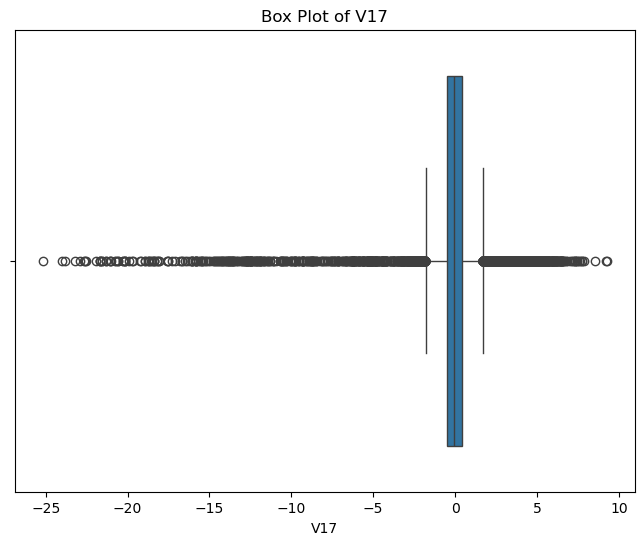

In [28]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
sns.boxplot(x=df['V17'])
plt.title('Box Plot of V17')
plt.show()

In [29]:
xgb_model = XGBClassifier(n_estimators=400, learning_rate=0.1, max_depth=3, use_label_encoder=False)
xgb_model.fit(X_train, y_train)
xgb_predictions = xgb_model.predict(X_test)
xgb_predictions_proba = xgb_model.predict_proba(X_test)[:,1]
accuracy_score(y_test,xgb_predictions)

0.9995786566168468

In [30]:
# 1. scale_pos_weight 계산
pos_count = np.sum(y_train == 1)
neg_count = np.sum(y_train == 0)
pos_weight = neg_count / pos_count
print(f"Calculated scale_pos_weight: {pos_weight:.2f}")

xgb_model = XGBClassifier(
    n_estimators=1000, # n_estimators를 충분히 높게 설정하고 early stopping을 고려
    learning_rate=0.05, # learning_rate를 조금 낮춰서 더 정교하게 학습
    max_depth=5,        # 깊이를 약간 늘려 복잡한 패턴 학습 유도
    min_child_weight=1, # 기본값 1 유지 또는 더 낮게 (불균형 데이터에서는 1이 적절)
    gamma=0.1,          # 작은 gamma 값으로 더 많은 분할 유도
    subsample=0.7,
    colsample_bytree=0.7,
    scale_pos_weight=pos_weight, # <<< 가장 중요한 파라미터
    objective='binary:logistic', # 이진 분류 기본 objective
    eval_metric='aucpr', # 훈련 중 평가 지표. Recall 대신 AUCPR도 불균형 데이터에 좋음.
    use_label_encoder=False,
    random_state=42,
    n_jobs=-1
)

# Early Stopping을 사용하여 과적합 방지 및 최적의 n_estimators 찾기
# 검증 데이터셋 (X_test, y_test) 대신 X_val, y_val을 사용하는 것이 더 좋지만,
# 간단한 예시를 위해 X_train, y_train과 동일한 데이터를 사용합니다.
# 실제로는 X_train을 다시 분리하여 검증셋을 만드는 것이 좋습니다.
xgb_model.fit(X_train, y_train,
              early_stopping_rounds=50, # 50번 동안 검증 점수가 개선되지 않으면 훈련 중단
              eval_set=[(X_test, y_test)], # 검증 세트 (실제로는 X_val, y_val 사용 권장)
              verbose=False # 훈련 과정 출력 생략
             )

xgb_predictions = xgb_model.predict(X_test)
xgb_predictions_proba = xgb_model.predict_proba(X_test)[:,1]

print(f"Accuracy: {accuracy_score(y_test, xgb_predictions):.4f}")
print(f"Recall: {recall_score(y_test, xgb_predictions):.4f}") # <<< 목표 지표 확인
print(f"Precision: {precision_score(y_test, xgb_predictions):.4f}")
print(f"F1-Score: {f1_score(y_test, xgb_predictions):.4f}")
print(f"ROC-AUC: {roc_auc_score(y_test, xgb_predictions_proba):.4f}")

Calculated scale_pos_weight: 581.93
Accuracy: 0.9996
Recall: 0.8493
Precision: 0.9051
F1-Score: 0.8763
ROC-AUC: 0.9858


In [31]:
confusion_matrix(y_test, xgb_predictions)
print(classification_report(y_test, xgb_predictions))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     85295
           1       0.91      0.85      0.88       146

    accuracy                           1.00     85441
   macro avg       0.95      0.92      0.94     85441
weighted avg       1.00      1.00      1.00     85441



In [32]:
# 모델 학습 (위에서 사용하신 코드 그대로)
# xgb_model.fit(X_train, y_train, ...)

# 예측 확률 얻기
xgb_predictions_proba = xgb_model.predict_proba(X_test)[:, 1]

# 다양한 임계값으로 재현율과 정밀도 확인
thresholds = np.arange(0.1, 0.5, 0.05) # 0.1부터 0.45까지 0.05 간격으로 시도
# 또는 더 세밀하게 np.arange(0.01, 0.5, 0.01)

print("--- Threshold Tuning Results ---")
for threshold in thresholds:
    y_pred_tuned = (xgb_predictions_proba >= threshold).astype(int)
    recall = recall_score(y_test, y_pred_tuned)
    precision = precision_score(y_test, y_pred_tuned)
    f1 = f1_score(y_test, y_pred_tuned)
    print(f"Threshold: {threshold:.2f} | Recall: {recall:.4f} | Precision: {precision:.4f} | F1-Score: {f1:.4f}")

# 최적의 임계값 선택 후 최종 평가
# 예를 들어, 0.85보다 높은 재현율을 달성하면서 정밀도 손실이 너무 크지 않은 지점 선택
optimal_threshold = 0.25 # 예시 값, 위 출력 결과에 따라 조절

y_pred_final = (xgb_predictions_proba >= optimal_threshold).astype(int)
print(f"\n--- Final Evaluation with Threshold {optimal_threshold:.2f} ---")
print(f"Recall: {recall_score(y_test, y_pred_final):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_final):.4f}")
print(f"F1-Score: {f1_score(y_test, y_pred_final):.4f}")
print(f"ROC-AUC: {roc_auc_score(y_test, xgb_predictions_proba):.4f}")
print(f"Actual Fraud Cases: {np.sum(y_test == 1)}")
print(f"Predicted Fraud Cases: {np.sum(y_pred_final == 1)}")
print(f"Correctly Predicted Fraud Cases (True Positives): {np.sum((y_test == 1) & (y_pred_final == 1))}")

--- Threshold Tuning Results ---
Threshold: 0.10 | Recall: 0.8767 | Precision: 0.7151 | F1-Score: 0.7877
Threshold: 0.15 | Recall: 0.8767 | Precision: 0.7950 | F1-Score: 0.8339
Threshold: 0.20 | Recall: 0.8699 | Precision: 0.8411 | F1-Score: 0.8552
Threshold: 0.25 | Recall: 0.8562 | Precision: 0.8681 | F1-Score: 0.8621
Threshold: 0.30 | Recall: 0.8562 | Precision: 0.8681 | F1-Score: 0.8621
Threshold: 0.35 | Recall: 0.8493 | Precision: 0.8732 | F1-Score: 0.8611
Threshold: 0.40 | Recall: 0.8493 | Precision: 0.8857 | F1-Score: 0.8671
Threshold: 0.45 | Recall: 0.8493 | Precision: 0.9051 | F1-Score: 0.8763

--- Final Evaluation with Threshold 0.25 ---
Recall: 0.8562
Precision: 0.8681
F1-Score: 0.8621
ROC-AUC: 0.9858
Actual Fraud Cases: 146
Predicted Fraud Cases: 144
Correctly Predicted Fraud Cases (True Positives): 125
